In [1]:
# outlier 
import numpy as np

In [40]:
arr = np.array([ -34, 1,2,3, 12, 15,76, 20, 80])

In [41]:
# outlier 
# IQR
# box plot 
# trimming
# capping 


In [42]:
import matplotlib.pyplot as plt

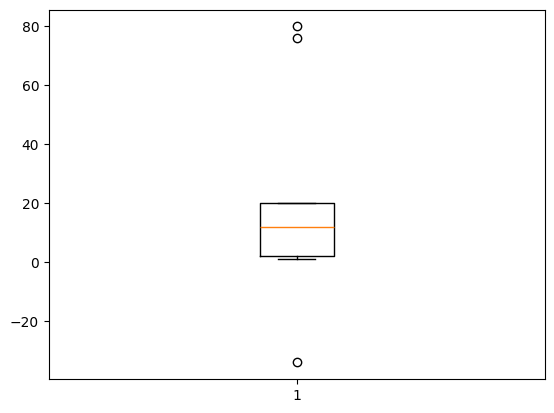

In [43]:
plt.boxplot(arr)
plt.show()

In [44]:
# 25%, 50%, 75% => Q1, Q2, Q3

In [45]:
# IQR = Q3 - Q1
Q1 = np.quantile(arr, 0.25)
Q2 = np.quantile(arr, 0.5)
Q3 = np.quantile(arr, 0.75)

In [46]:
IQR = Q3 - Q1
IQR

np.float64(18.0)

In [47]:
upper = Q3 + 1.5 * IQR
lower  = Q1 - 1.5* IQR

In [48]:
upper, lower

(np.float64(47.0), np.float64(-25.0))

In [53]:
arr[~((arr< lower) | (arr > upper))] # and or not &, | ~

array([ 1,  2,  3, 12, 15, 20])

In [54]:
arr

array([-34,   1,   2,   3,  12,  15,  76,  20,  80])

In [59]:
arr[arr<lower] = lower
arr[arr>upper] = upper

In [60]:
arr

array([-25,   1,   2,   3,  12,  15,  47,  20,  47])

In [62]:
# arr[arr >lower] 

array([ 1,  2,  3, 12, 15, 47, 20, 47])

In [63]:
arr

array([-25,   1,   2,   3,  12,  15,  47,  20,  47])

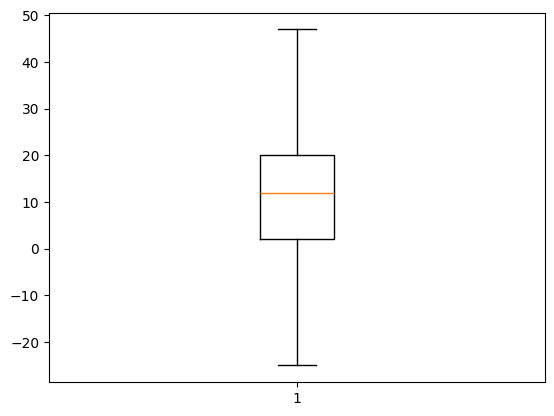

In [64]:
plt.boxplot(arr)
plt.show()

In [66]:
import pandas as pd
df = pd.read_csv('../../../DataScience_Morning/data/IRIS.csv')

In [67]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


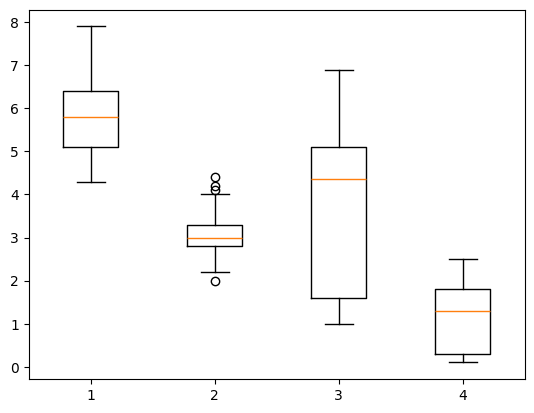

In [71]:
plt.boxplot([df['sepal_length'], df['sepal_width'], df['petal_length'], df['petal_width']])
plt.show()

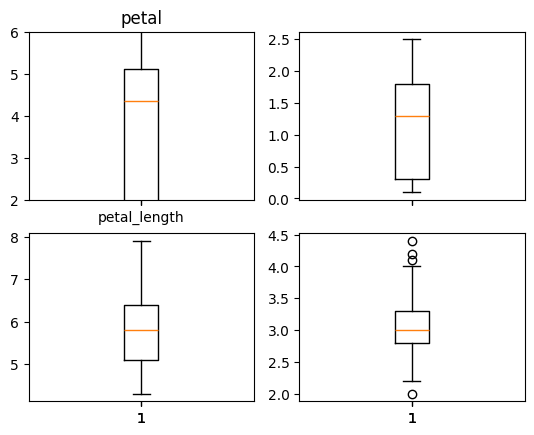

In [142]:
fig, ax = plt.subplots(2,2, sharex=True, sharey=False)
ax[0,0].boxplot(df['petal_length'])
# ax[0,0].set_xlabel('petal_length')
ax[0,0].set(title='petal', xlabel='petal_length', ylim=(2,6))

ax[0,1].boxplot(df['petal_width'])
ax[1,0].boxplot(df['sepal_length'])
ax[1,1].boxplot(df['sepal_width'])
plt.show()

In [93]:
# Q1, Q3 
Q1 = df['sepal_width'].quantile(0.25) # percentile 

In [94]:
Q1

np.float64(2.8)

In [77]:
data = df.describe()

In [82]:
data.index

Index(['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max'], dtype='str')

In [88]:
Q1, Q2, Q3 = data.loc['25%': '75%', 'sepal_width'].to_numpy()

In [89]:
Q1

np.float64(2.8)

In [90]:
Q2, Q3

(np.float64(3.0), np.float64(3.3))

In [96]:
IQR = Q3 - Q1
IQR

np.float64(0.5)

In [100]:
upper = Q3 + 1.5* IQR
lower = Q1 - 1.5 * IQR

In [101]:
upper, lower

(np.float64(4.05), np.float64(2.05))

In [105]:
mask = (df['sepal_width']< lower) | (df['sepal_width']> upper) # boolean masking
df.loc[mask]

,sepal_length,sepal_width,petal_length,petal_width,species
15,5.7,4.4,1.5,0.4,Iris-setosa
32,5.2,4.1,1.5,0.1,Iris-setosa
33,5.5,4.2,1.4,0.2,Iris-setosa
60,5.0,2.0,3.5,1.0,Iris-versicolor


In [112]:
df['sepal_width'].clip(lower, upper)

0      3.5
1      3.0
2      3.2
3      3.1
4      3.6
      ... 
145    3.0
146    2.5
147    3.0
148    3.4
149    3.0
Name: sepal_width, Length: 150, dtype: float64

In [107]:
s = pd.Series(arr)

In [111]:
s.clip(1, 40)

0     1
1     1
2     2
3     3
4    12
5    15
6    40
7    20
8    40
dtype: int64

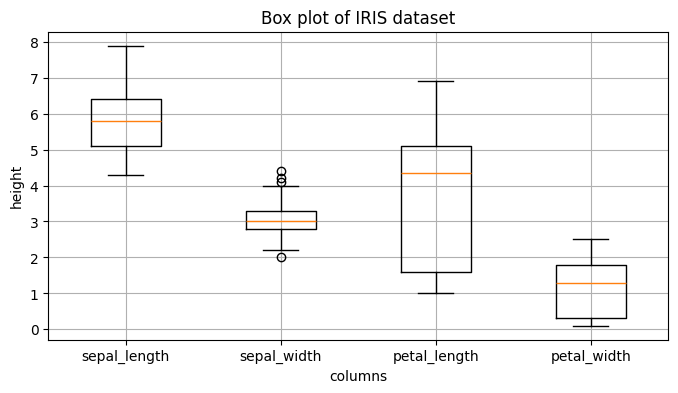

In [131]:
plt.figure(figsize=(8,4))
plt.boxplot([df['sepal_length'], df['sepal_width'], df['petal_length'], df['petal_width']])
plt.xticks( range(1,len(df.columns)),  df.columns[:-1])
plt.xlabel("columns")
plt.ylabel("height")
plt.title("Box plot of IRIS dataset")
plt.grid()
plt.show()

In [114]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

In [115]:
1-4 
[1,2,3,4], ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

([1, 2, 3, 4], ['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])